In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("Fact_marketing.csv")
dim_date = pd.read_csv("dim_date.csv")

In [ ]:
target_col = 'new_beneficiaries'
feature_col = 'marketing_spend'

df = df[[feature_col, target_col]].copy()

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   marketing_spend    36 non-null     int64
 1   new_beneficiaries  36 non-null     int64
dtypes: int64(2)
memory usage: 708.0 bytes
None


,marketing_spend,new_beneficiaries
0,29217,1568
1,142420,1166
2,24307,1488
3,28777,745
4,18688,1540


In [ ]:
# Convert to numeric just in case
df[feature_col] = pd.to_numeric(df[feature_col], errors='coerce')
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Remove impossible values if needed
df = df[df[feature_col] >= 0]
df = df[df[target_col] >= 0]

print("Cleaned shape:", df.shape)
df.describe()

Cleaned shape: (36, 2)


,marketing_spend,new_beneficiaries
count,36.000000,36.000000
mean,20977.666667,1131.833333
std,23632.220420,573.646058
min,2669.000000,75.000000
25%,10508.750000,802.750000
50%,15930.000000,1248.000000
75%,24619.750000,1547.000000
max,142420.000000,1982.000000


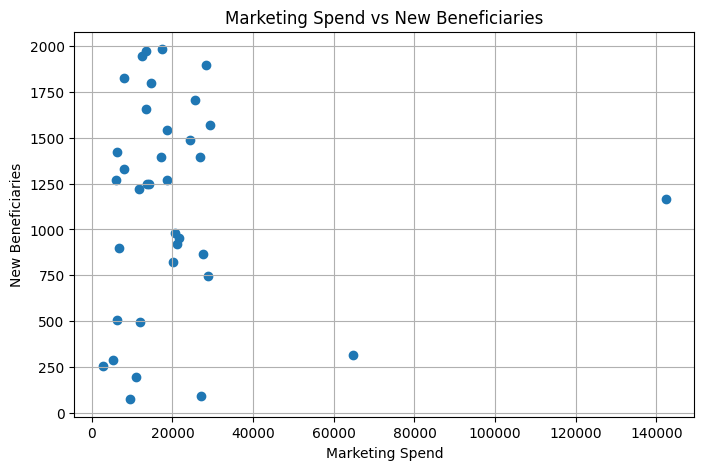

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df[feature_col], df[target_col])
plt.xlabel('Marketing Spend')
plt.ylabel('New Beneficiaries')
plt.title('Marketing Spend vs New Beneficiaries')
plt.grid(True)
plt.show()

In [ ]:
# =========================
# CELL 7 - PREPARE FEATURES / TARGET
# =========================
X = df[[feature_col]]
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (36, 1)
y shape: (36,)


In [ ]:
# =========================
# CELL 8 - TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 28
Test size: 8


In [ ]:
# =========================
# CELL 9 - DEFINE MODELS
# =========================
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )
}

In [ ]:
# =========================
# CELL 10 - TRAIN & EVALUATE
# =========================
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
results_df

,Model,MSE,RMSE,MAE,R2
3,Random Forest,110295.675833,332.107928,308.996979,0.240579
1,Ridge Regression,231366.999401,481.006236,384.812129,-0.593035
2,Lasso Regression,231803.098005,481.459342,384.925631,-0.596038
0,Linear Regression,231835.015054,481.492487,384.933927,-0.596257


In [13]:
# =========================
# CELL 11 - K-FOLD VALIDATION
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    neg_mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')

    mse_mean = -neg_mse_scores.mean()
    rmse_mean = np.sqrt(mse_mean)
    mae_mean = -mae_scores.mean()
    r2_mean = r2_scores.mean()

    cv_results.append({
        "Model": name,
        "CV_MSE": mse_mean,
        "CV_RMSE": rmse_mean,
        "CV_MAE": mae_mean,
        "CV_R2": r2_mean
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_R2", ascending=False)
cv_results_df

,Model,CV_MSE,CV_RMSE,CV_MAE,CV_R2
3,Random Forest,353217.315961,594.320886,500.812948,-0.105551
1,Ridge Regression,394574.146007,628.151372,532.101864,-0.371868
2,Lasso Regression,397822.967047,630.732088,533.575929,-0.379706
0,Linear Regression,397930.629163,630.817429,533.628467,-0.379992


In [14]:
# =========================
# CELL 12 - SELECT BEST MODEL
# =========================
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


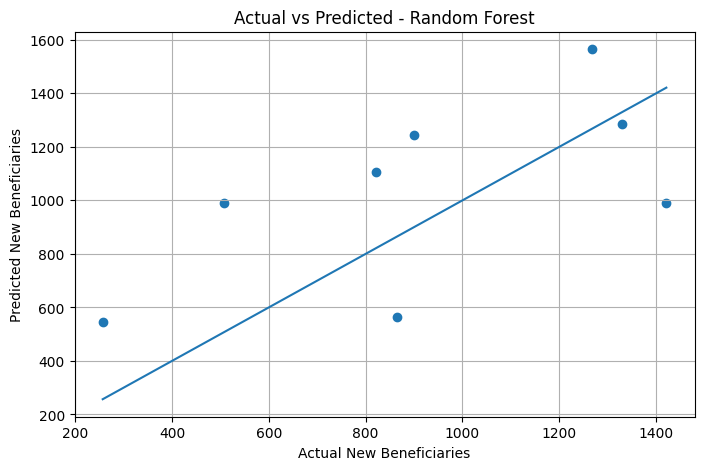

In [15]:
# =========================
# CELL 13 - ACTUAL VS PREDICTED
# =========================
best_pred = predictions[best_model_name]

plt.figure(figsize=(8,5))
plt.scatter(y_test, best_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual New Beneficiaries")
plt.ylabel("Predicted New Beneficiaries")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.grid(True)
plt.show()

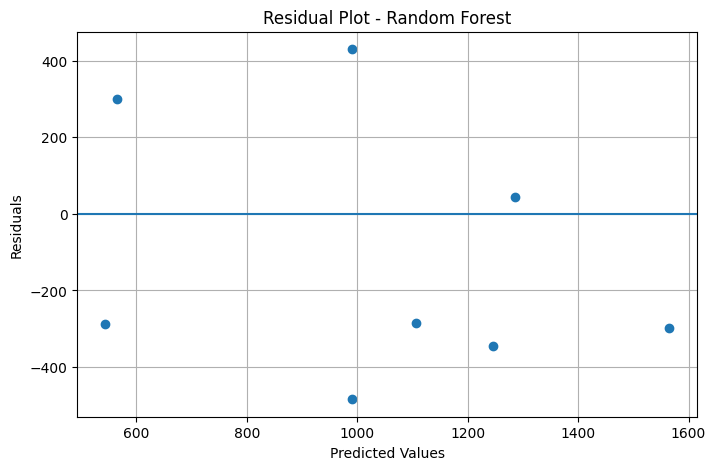

In [16]:
# =========================
# CELL 14 - RESIDUAL PLOT
# =========================
residuals = y_test - best_pred

plt.figure(figsize=(8,5))
plt.scatter(best_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")
plt.grid(True)
plt.show()

           Feature  Importance
0  marketing_spend         1.0


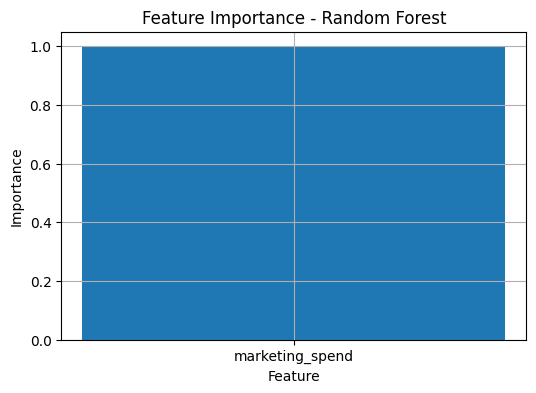

In [17]:
# =========================
# CELL 15 - EXPLAINABILITY
# =========================
if best_model_name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
    scaler = best_model.named_steps["scaler"]
    reg = best_model.named_steps["model"]

    print("Intercept:", reg.intercept_)
    print("Coefficient for marketing_spend:", reg.coef_[0])

elif best_model_name == "Random Forest":
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print(feature_importance_df)

    plt.figure(figsize=(6,4))
    plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
    plt.title("Feature Importance - Random Forest")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.grid(True)
    plt.show()

In [18]:
# =========================
# CELL 16 - PREDICT FOR A GIVEN SPEND
# =========================
example_spend = pd.DataFrame({"marketing_spend": [500]})
predicted_beneficiaries = best_model.predict(example_spend)[0]

print(f"If marketing spend = 500, predicted new beneficiaries = {predicted_beneficiaries:.2f}")

If marketing spend = 500, predicted new beneficiaries = 543.83


In [19]:
# =========================
# CELL 17 - BUDGET SIMULATION
# =========================
min_spend = df[feature_col].min()
max_spend = df[feature_col].max()

spend_values = np.linspace(min_spend, max_spend, 50)
simulation_df = pd.DataFrame({feature_col: spend_values})
simulation_df["predicted_beneficiaries"] = best_model.predict(simulation_df)

simulation_df.head()

,marketing_spend,predicted_beneficiaries
0,2669.000000,543.825000
1,5521.061224,543.825000
2,8373.122449,1283.808333
3,11225.183673,491.819826
4,14077.244898,1428.923264


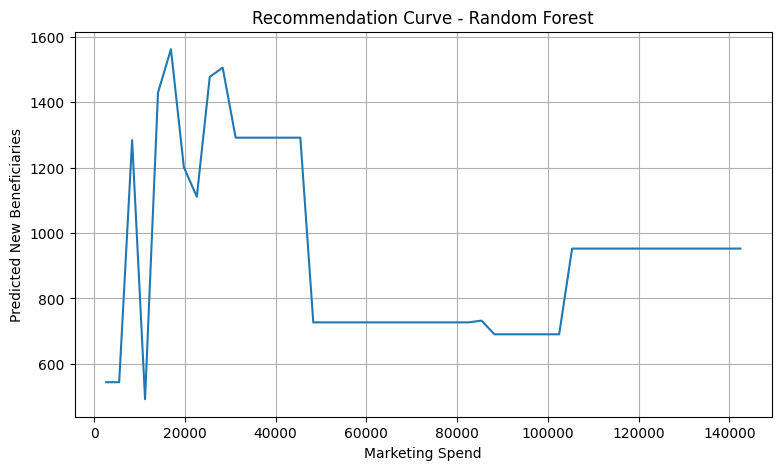

In [20]:
# =========================
# CELL 18 - RECOMMENDATION CURVE
# =========================
plt.figure(figsize=(9,5))
plt.plot(simulation_df[feature_col], simulation_df["predicted_beneficiaries"])
plt.xlabel("Marketing Spend")
plt.ylabel("Predicted New Beneficiaries")
plt.title(f"Recommendation Curve - {best_model_name}")
plt.grid(True)
plt.show()

In [21]:
# =========================
# CELL 19 - SPEND NEEDED FOR TARGET BENEFICIARIES
# =========================
target_beneficiaries = 100  # change this value

simulation_df["difference"] = abs(simulation_df["predicted_beneficiaries"] - target_beneficiaries)
best_row = simulation_df.loc[simulation_df["difference"].idxmin()]

print(f"Target beneficiaries: {target_beneficiaries}")
print(f"Recommended marketing spend: {best_row[feature_col]:.2f}")
print(f"Predicted beneficiaries at this spend: {best_row['predicted_beneficiaries']:.2f}")

Target beneficiaries: 100
Recommended marketing spend: 11225.18
Predicted beneficiaries at this spend: 491.82


In [22]:
# =========================
# CELL 20 - FINAL SUMMARY
# =========================
print("========== FINAL ML SUMMARY ==========")
print(f"Dataset size: {df.shape[0]} rows")
print(f"Feature used: {feature_col}")
print(f"Target used: {target_col}")
print(f"Best model: {best_model_name}")

best_row_metrics = results_df.iloc[0]
print(f"MSE  : {best_row_metrics['MSE']:.4f}")
print(f"RMSE : {best_row_metrics['RMSE']:.4f}")
print(f"MAE  : {best_row_metrics['MAE']:.4f}")
print(f"R2   : {best_row_metrics['R2']:.4f}")

========== FINAL ML SUMMARY ==========
Dataset size: 36 rows
Feature used: marketing_spend
Target used: new_beneficiaries
Best model: Random Forest
MSE  : 110295.6758
RMSE : 332.1079
MAE  : 308.9970
R2   : 0.2406
